Data Mining Methods to Make Predictions - 3/29/2026 - April Taylor

In [1]:
#Import required
import pandas as pd

#Dataset read
df = pd.read_excel("C:\\Files\\Excel\\StudentsPerformance.xlsx")

#Display first few rows
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [2]:
#Encode categorical variables to prepare the dataset for modeling
categorical_cols = [
    "gender", 
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.head()
    

,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,72,74,False,True,False,False,False,True,False,False,False,False,True,True
1,69,90,88,False,False,True,False,False,False,False,False,True,False,True,False
2,90,95,93,False,True,False,False,False,False,False,True,False,False,True,True
3,47,57,44,True,False,False,False,False,False,False,False,False,False,False,True
4,76,78,75,True,False,True,False,False,False,False,False,True,False,True,True


In [3]:
#Import required
from sklearn.model_selection import train_test_split

#Splits encoded dataset into trainig and testing sets for predicting math scores
X = df_encoded.drop("math score", axis=1)
Y = df_encoded["math score"]

X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.20, random_state=42)


In [4]:
#Import required
from sklearn.linear_model import LinearRegression

#Train linear regression model using training data
model = LinearRegression()
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
#Import required
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Generate predictions using trained model
Y_pred = model.predict(X_test)

#Statistical computations 
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

#Display metrics
mae, mse, r2

(4.214763142474852, 29.095169866715494, 0.8804332983749564)

In [6]:
#Dataframe to show each feature with its coefficient
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
}).sort_values(by="coefficient", ascending=False)

#Display table
coef_df

,feature,coefficient
2,gender_male,13.064884
6,race/ethnicity_group E,4.892649
12,lunch_standard,3.510075
13,test preparation course_none,3.289642
10,parental level of education_some college,0.998856
8,parental level of education_high school,0.929312
11,parental level of education_some high school,0.756470
1,writing score,0.724148
3,race/ethnicity_group B,0.359323
0,reading score,0.236023


Project: Prescriptive Analytics - 4/5/2026 - aprtay2887
#Actionable Features
Reading scores and lunch status are actionable features because schools can directly influence them through academic support
and nutrition progams. Improving reading performance through turtoring or curriculum changes can raise overall academic achievement.

In [14]:
#Imports required
import numpy as np
import pandas as pd

template = X.columns

#Subset students below the median math sore
median_math = df["math score"].median()
subset = df[df["math score"] < median_math].copy()
subset_encoded_before = pd.get_dummies(subset, drop_first=True)
subset_encoded_before = subset_encoded_before.reindex(columns=template, fill_value=0)

#Prediction of baseline math scores
subset["pred_before"] = model.predict(subset_encoded_before)

subset.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,pred_before
3,male,group A,associate's degree,free/reduced,none,47,57,44,50.757824
7,male,group B,some college,free/reduced,none,40,43,39,45.190948
8,male,group D,high school,free/reduced,completed,64,64,67,66.091818
9,female,group B,high school,free/reduced,none,38,60,50,44.034531
10,male,group C,associate's degree,standard,none,58,54,52,58.727398


In [15]:
#Interventions
#Increase reading score (5%)
subset["reading score"] = subset["reading score"] * 1.05

#Reduced lunch (5%)
free_reduced_idx = subset[subset["lunch"] == "free/reduced"].sample(
    frac=0.05, random_state=42
).index
subset.loc[free_reduced_idx, :"lunch"] = "standard"

#Encode lunch 
subset_encoded_after = pd.get_dummies(subset, drop_first=True)
subset_encoded_after = subset_encoded_after.reindex(columns=template, fill_value=0)

#prediction after interventions
subset["pred_after"] = model.predict(subset_encoded_after)
subset[["math score", "pred_before", "pred_after"]].head()

,math score,pred_before,pred_after
3,47,50.757824,51.430488
7,40,45.190948,45.698396
8,64,66.091818,66.847090
9,38,44.034531,44.742598
10,58,58.727398,59.364659


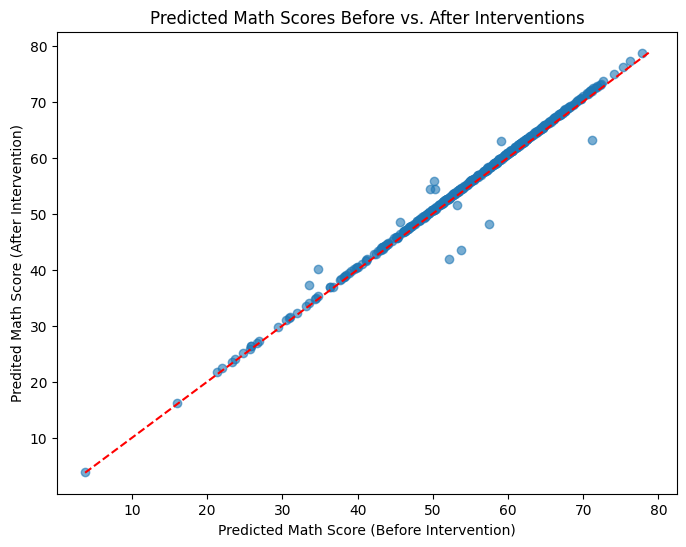

In [17]:
#imports required
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(subset["pred_before"], subset["pred_after"], alpha=0.6)

plt.xlabel("Predicted Math Score (Before Intervention)")
plt.ylabel("Predited Math Score (After Intervention)")
plt.title("Predicted Math Scores Before vs. After Interventions")

min_val = min(subset["pred_before"].min(), subset["pred_after"].min())
max_val = max(subset["pred_before"].max(), subset["pred_after"].max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")

plt.show()